# Анализ доходности и волатильности криптовалют

**Авторы:** Козлов Степан, Шембек Александр - РИС-24-1

## Цель проекта

Цель проекта — проанализировать историческую доходность и волатильность крупнейших криптовалют за последний год на основе данных CoinGecko API.

В работе рассматриваются 8 криптовалют, выбранных так, чтобы сравнить разные типы активов внутри криптовалютного рынка.

| Криптовалюта | Тикер | Почему выбрана |
|---|---|---|
| Bitcoin | BTC | Крупнейшая и наиболее известная криптовалюта, часто используется как ориентир для всего рынка. |
| Ethereum | ETH | Вторая по значимости криптовалюта, основа крупной экосистемы смарт-контрактов и DeFi-проектов. |
| Binance Coin | BNB | Крупная биржевая и экосистемная монета, связанная с Binance и BNB Chain. |
| Solana | SOL | Популярная блокчейн-платформа с высокой волатильностью, интересна для сравнения с BTC и ETH. |
| Ripple | XRP | Крупная криптовалюта с отдельной рыночной динамикой, связанная с платежной инфраструктурой. |
| Dogecoin | DOGE | Мем-коин, который часто отличается высокой волатильностью и зависимостью от рыночных настроений. |
| Cardano | ADA | Один из известных Layer-1 проектов, позволяет сравнить динамику крупных альтернативных блокчейнов. |
| Tron | TRX | Криптовалюта сети TRON, активно используемой для переводов стейблкоинов, особенно USDT. |

## Исследовательские вопросы 

В рамках проекта рассматриваются не только отдельные показатели доходности и риска, но и несколько исследовательских вопросов.

**Гипотеза 1.** Bitcoin и Ethereum как крупнейшие криптовалюты имеют более низкую волатильность по сравнению с большинством альткоинов.

**Гипотеза 2.** Криптовалюты с более высокой доходностью обычно связаны с более высоким уровнем риска.

**Гипотеза 3.** Доходности криптовалют положительно коррелируют между собой, так как рынок криптовалют часто движется под влиянием общих факторов.

**Гипотеза 4.** Мемкоин DOGE отличается более нестабильной динамикой по сравнению с крупными инфраструктурными криптовалютами.

## Источник данных

Данные получены через CoinGecko API. Используется endpoint market_chart, который позволяет получить исторические данные по цене, рыночной капитализации и объёму торгов.

In [3]:
import time
import os

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

## 1. Настройка API

Для получения данных используется CoinGecko Demo API.  
API-ключ не хранится в ноутбуке.  
Если переменная окружения `COINGECKO_API_KEY` не задана, ноутбук попробует загрузить данные из файла `raw_crypto_data.csv`.  
Если нет ни API-ключа, ни локального файла, будет выведена ошибка.

In [4]:
load_dotenv()

API_KEY = os.getenv("COINGECKO_API_KEY")

DATA_FILE = "raw_crypto_data.csv"
USE_LOCAL_DATA = API_KEY is None

if USE_LOCAL_DATA and not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        "API-ключ CoinGecko не найден, и файл raw_crypto_data.csv отсутствует. "
        "Добавьте ключ COINGECKO_API_KEY или положите raw_crypto_data.csv рядом с ноутбуком."
    )

BASE_URL = "https://api.coingecko.com/api/v3"

headers = {
    "x-cg-demo-api-key": API_KEY
} if API_KEY else {}

In [5]:
coins = {
    "BTC": "bitcoin",
    "ETH": "ethereum",
    "BNB": "binancecoin",
    "SOL": "solana",
    "XRP": "ripple",
    "DOGE": "dogecoin",
    "ADA": "cardano",
    "TRX": "tron"
}

coins

{'BTC': 'bitcoin',
 'ETH': 'ethereum',
 'BNB': 'binancecoin',
 'SOL': 'solana',
 'XRP': 'ripple',
 'DOGE': 'dogecoin',
 'ADA': 'cardano',
 'TRX': 'tron'}

## 2. Сбор данных

На этом этапе данные собираются через CoinGecko API или загружаются из локального CSV-файла.  
Для каждой криптовалюты загружаются исторические данные за последние 365 дней:

- цена;
- рыночная капитализация;
- объём торгов.

Для соблюдения лимитов API между запросами добавляется небольшая пауза.

In [6]:
def get_coin_market_data(coin_id, symbol, days=365):
    """
    Получает исторические данные по криптовалюте из CoinGecko API.

    Параметры:
    coin_id: str — CoinGecko ID криптовалюты
    symbol: str — тикер криптовалюты
    days: int — количество дней для анализа

    Возвращает:
    DataFrame с датой, ценой, капитализацией, объёмом торгов и тикером.
    """
    
    url = f"{BASE_URL}/coins/{coin_id}/market_chart"
    
    params = {
        "vs_currency": "usd",
        "days": days,
        "interval": "daily"
    }
    
    response = requests.get(url, params=params, headers=headers)
    
    if response.status_code != 200:
        print(f"Ошибка для {symbol}: {response.status_code}")
        print(response.text)
        return None
    
    data = response.json()
    
    prices = pd.DataFrame(data["prices"], columns=["timestamp", "price"])
    market_caps = pd.DataFrame(data["market_caps"], columns=["timestamp", "market_cap"])
    volumes = pd.DataFrame(data["total_volumes"], columns=["timestamp", "total_volume"])
    
    df = prices.merge(market_caps, on="timestamp")
    df = df.merge(volumes, on="timestamp")
    
    df["date"] = pd.to_datetime(df["timestamp"], unit="ms").dt.date
    df["symbol"] = symbol
    df["coin_id"] = coin_id
    
    df = df[["date", "symbol", "coin_id", "price", "market_cap", "total_volume"]]
    
    return df

In [7]:
if USE_LOCAL_DATA:
    print(f"API-ключ не найден. Загружаю данные из {DATA_FILE}...")
    crypto_data = pd.read_csv(DATA_FILE)
else:
    all_data = []

    for symbol, coin_id in coins.items():
        print(f"Загружаю данные для {symbol}...")
    
        coin_data = get_coin_market_data(coin_id=coin_id, symbol=symbol, days=365)
    
        if coin_data is not None:
            all_data.append(coin_data)
    
        time.sleep(1.2)

    if not all_data:
        raise ValueError("Не удалось загрузить данные из CoinGecko API.")

    crypto_data = pd.concat(all_data, ignore_index=True)

crypto_data.head()

API-ключ не найден. Загружаю данные из raw_crypto_data.csv...


,date,symbol,coin_id,price,market_cap,total_volume
0,2025-06-17,BTC,bitcoin,106951.272018,2.127895e+12,3.209596e+10
1,2025-06-18,BTC,bitcoin,104683.424798,2.080968e+12,3.860321e+10
2,2025-06-19,BTC,bitcoin,104722.695053,2.081678e+12,3.033933e+10
3,2025-06-20,BTC,bitcoin,104690.650025,2.081355e+12,1.806328e+10
4,2025-06-21,BTC,bitcoin,103290.105145,2.054120e+12,3.063275e+10


In [8]:
crypto_data.shape

(2928, 6)

In [9]:
if USE_LOCAL_DATA:
    print(f"Данные загружены из {DATA_FILE}; файл не перезаписывается.")
else:
    crypto_data.to_csv(DATA_FILE, index=False)
    print(f"Полученные данные сохранены в файл {DATA_FILE}")

Данные загружены из raw_crypto_data.csv; файл не перезаписывается.


## Промежуточный вывод

На первом этапе были собраны исторические данные по 8 криптовалютам за последние 365 дней.  
Данные включают цену, рыночную капитализацию и объём торгов.

Полученный датасет будет использоваться для дальнейшей очистки, создания новых признаков и анализа доходности и волатильности.

## 3. Первичный осмотр данных

После сбора данных необходимо проверить структуру таблицы:

- количество строк и столбцов;
- типы данных;
- наличие пропущенных значений;
- наличие дубликатов;
- корректность дат и числовых признаков.

Это позволит понять, требуется ли дополнительная очистка перед анализом.

In [10]:
print("Размер датасета:", crypto_data.shape)

display(crypto_data.head())

crypto_data.info()

Размер датасета: (2928, 6)


,date,symbol,coin_id,price,market_cap,total_volume
0,2025-06-17,BTC,bitcoin,106951.272018,2.127895e+12,3.209596e+10
1,2025-06-18,BTC,bitcoin,104683.424798,2.080968e+12,3.860321e+10
2,2025-06-19,BTC,bitcoin,104722.695053,2.081678e+12,3.033933e+10
3,2025-06-20,BTC,bitcoin,104690.650025,2.081355e+12,1.806328e+10
4,2025-06-21,BTC,bitcoin,103290.105145,2.054120e+12,3.063275e+10


<class 'pandas.DataFrame'>
RangeIndex: 2928 entries, 0 to 2927
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2928 non-null   str    
 1   symbol        2928 non-null   str    
 2   coin_id       2928 non-null   str    
 3   price         2928 non-null   float64
 4   market_cap    2928 non-null   float64
 5   total_volume  2928 non-null   float64
dtypes: float64(3), str(3)
memory usage: 137.4 KB


In [11]:
missing_values = crypto_data.isna().sum().to_frame("missing_count")
display(missing_values)

duplicate_count = crypto_data.duplicated().sum()
print("Количество полных дубликатов:", duplicate_count)

,missing_count
date,0
symbol,0
coin_id,0
price,0
market_cap,0
total_volume,0


Количество полных дубликатов: 0


## 4. Очистка и приведение типов данных

На этом этапе выполняется базовая предобработка:

- дата приводится к формату `datetime`;
- числовые столбцы приводятся к числовому типу;
- данные сортируются по криптовалюте и дате;
- удаляются дубликаты по паре `symbol` и `date`;
- пропуски в числовых значениях заполняются внутри каждой криптовалюты.

Так как резкие изменения цены являются естественной особенностью криптовалютного рынка, такие наблюдения не удаляются автоматически, а рассматриваются как часть анализа волатильности.

In [12]:
crypto_clean = crypto_data.copy()

crypto_clean["date"] = pd.to_datetime(crypto_clean["date"])

numeric_columns = ["price", "market_cap", "total_volume"]

for column in numeric_columns:
    crypto_clean[column] = pd.to_numeric(crypto_clean[column], errors="coerce")

crypto_clean = crypto_clean.sort_values(["symbol", "date"]).reset_index(drop=True)

crypto_clean = crypto_clean.drop_duplicates(
    subset=["symbol", "date"],
    keep="last"
)

crypto_clean[numeric_columns] = (
    crypto_clean
    .groupby("symbol")[numeric_columns]
    .transform(lambda values: values.ffill().bfill())
)

crypto_clean = crypto_clean.dropna(subset=numeric_columns)

display(crypto_clean.head())
crypto_clean.info()

,date,symbol,coin_id,price,market_cap,total_volume
0,2025-06-17,ADA,cardano,0.634809,2.297946e+10,6.343460e+08
1,2025-06-18,ADA,cardano,0.611422,2.207139e+10,6.687805e+08
2,2025-06-19,ADA,cardano,0.603152,2.178332e+10,6.494329e+08
3,2025-06-20,ADA,cardano,0.602252,2.175192e+10,4.115261e+08
4,2025-06-21,ADA,cardano,0.576848,2.083164e+10,6.550894e+08


<class 'pandas.DataFrame'>
Index: 2920 entries, 0 to 2927
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          2920 non-null   datetime64[us]
 1   symbol        2920 non-null   str           
 2   coin_id       2920 non-null   str           
 3   price         2920 non-null   float64       
 4   market_cap    2920 non-null   float64       
 5   total_volume  2920 non-null   float64       
dtypes: datetime64[us](1), float64(3), str(2)
memory usage: 159.7 KB


In [13]:
quality_check = crypto_clean.groupby("symbol").agg(
    first_date=("date", "min"),
    last_date=("date", "max"),
    observations=("date", "count"),
    min_price=("price", "min"),
    max_price=("price", "max")
).reset_index()

display(quality_check)

,symbol,first_date,last_date,observations,min_price,max_price
0,ADA,2025-06-17,2026-06-16,365,0.156707,0.963210
1,BNB,2025-06-17,2026-06-16,365,571.876112,1311.712915
2,BTC,2025-06-17,2026-06-16,365,60861.880129,124773.508231
3,DOGE,2025-06-17,2026-06-16,365,0.081318,0.289384
4,ETH,2025-06-17,2026-06-16,365,1568.766143,4829.225542
5,SOL,2025-06-17,2026-06-16,365,62.157877,247.556262
6,TRX,2025-06-17,2026-06-16,365,0.263612,0.375467
7,XRP,2025-06-17,2026-06-16,365,1.093158,3.556293


## Промежуточный вывод по очистке

После очистки данные были приведены к корректным типам.  
Каждая строка таблицы соответствует одной криптовалюте в конкретную дату.

На следующем этапе будут созданы новые расчетные признаки:

- дневная доходность;
- накопленная доходность;
- скользящая волатильность.

## 5. Создание признаков доходности

Доходность показывает, насколько изменилась цена актива относительно предыдущего дня.

В проекте рассчитываются:

1. Простая дневная доходность — процентное изменение цены за день.
2. Накопленная доходность — общий результат изменения цены за период.

In [14]:
crypto_clean["daily_return"] = (
    crypto_clean
    .groupby("symbol")["price"]
    .pct_change()
)

crypto_clean["cumulative_return"] = (
    crypto_clean
    .groupby("symbol")["price"]
    .transform(lambda prices: prices / prices.iloc[0] - 1)
)

crypto_clean["daily_return_pct"] = crypto_clean["daily_return"] * 100
crypto_clean["cumulative_return_pct"] = crypto_clean["cumulative_return"] * 100

display(crypto_clean.head(10))

,date,symbol,coin_id,price,market_cap,total_volume,daily_return,cumulative_return,daily_return_pct,cumulative_return_pct
0,2025-06-17,ADA,cardano,0.634809,2.297946e+10,6.343460e+08,NaN,0.000000,NaN,0.000000
1,2025-06-18,ADA,cardano,0.611422,2.207139e+10,6.687805e+08,-0.036841,-0.036841,-3.684058,-3.684058
2,2025-06-19,ADA,cardano,0.603152,2.178332e+10,6.494329e+08,-0.013527,-0.049869,-1.352654,-4.986880
3,2025-06-20,ADA,cardano,0.602252,2.175192e+10,4.115261e+08,-0.001493,-0.051287,-0.149266,-5.128702
4,2025-06-21,ADA,cardano,0.576848,2.083164e+10,6.550894e+08,-0.042181,-0.091305,-4.218119,-9.130486
5,2025-06-22,ADA,cardano,0.550708,1.986027e+10,6.163204e+08,-0.045315,-0.132482,-4.531469,-13.248210
6,2025-06-23,ADA,cardano,0.541130,1.953740e+10,1.046673e+09,-0.017393,-0.147570,-1.739253,-14.757044
7,2025-06-24,ADA,cardano,0.583240,2.105725e+10,9.233449e+08,0.077819,-0.081236,7.781856,-8.123560
8,2025-06-25,ADA,cardano,0.587219,2.119688e+10,7.167734e+08,0.006823,-0.074967,0.682283,-7.496703
9,2025-06-26,ADA,cardano,0.566772,2.047042e+10,5.494995e+08,-0.034821,-0.107177,-3.482057,-10.717720


## 6. Создание признаков волатильности

Волатильность показывает степень изменчивости цены актива.  
Чем выше волатильность, тем сильнее цена колебалась в рассматриваемом периоде.

В работе рассчитывается 30-дневная скользящая волатильность, приведенная к годовому масштабу.

Для каждого дня берутся дневные доходности за последние 30 дней и рассчитывается их стандартное отклонение. Затем результат умножается на `sqrt(365)`, чтобы перевести дневную волатильность в годовое выражение, так как криптовалюты торгуются ежедневно.

In [15]:
crypto_clean["volatility_30d"] = (
    crypto_clean
    .groupby("symbol")["daily_return"]
    .transform(lambda returns: returns.rolling(window=30).std() * np.sqrt(365))
)

crypto_clean["volatility_30d_pct"] = crypto_clean["volatility_30d"] * 100

display(crypto_clean.head(35))

,date,symbol,coin_id,price,market_cap,total_volume,daily_return,cumulative_return,daily_return_pct,cumulative_return_pct,volatility_30d,volatility_30d_pct
0,2025-06-17,ADA,cardano,0.634809,2.297946e+10,6.343460e+08,NaN,0.000000,NaN,0.000000,NaN,NaN
1,2025-06-18,ADA,cardano,0.611422,2.207139e+10,6.687805e+08,-0.036841,-0.036841,-3.684058,-3.684058,NaN,NaN
2,2025-06-19,ADA,cardano,0.603152,2.178332e+10,6.494329e+08,-0.013527,-0.049869,-1.352654,-4.986880,NaN,NaN
3,2025-06-20,ADA,cardano,0.602252,2.175192e+10,4.115261e+08,-0.001493,-0.051287,-0.149266,-5.128702,NaN,NaN
4,2025-06-21,ADA,cardano,0.576848,2.083164e+10,6.550894e+08,-0.042181,-0.091305,-4.218119,-9.130486,NaN,NaN
5,2025-06-22,ADA,cardano,0.550708,1.986027e+10,6.163204e+08,-0.045315,-0.132482,-4.531469,-13.248210,NaN,NaN
6,2025-06-23,ADA,cardano,0.541130,1.953740e+10,1.046673e+09,-0.017393,-0.147570,-1.739253,-14.757044,NaN,NaN
7,2025-06-24,ADA,cardano,0.583240,2.105725e+10,9.233449e+08,0.077819,-0.081236,7.781856,-8.123560,NaN,NaN
8,2025-06-25,ADA,cardano,0.587219,2.119688e+10,7.167734e+08,0.006823,-0.074967,0.682283,-7.496703,NaN,NaN
9,2025-06-26,ADA,cardano,0.566772,2.047042e+10,5.494995e+08,-0.034821,-0.107177,-3.482057,-10.717720,NaN,NaN


## 7. Сводная таблица по криптовалютам

Для сравнения криптовалют рассчитаем основные показатели:

- начальная цена;
- конечная цена;
- накопленная доходность;
- средняя дневная доходность;
- дневная волатильность;
- годовая волатильность;
- средний объем торгов;
- средняя рыночная капитализация;
- максимальная просадка.

Максимальная просадка показывает, насколько сильно цена снижалась от предыдущего максимума.

In [16]:
def calculate_max_drawdown(prices):
    """
    Рассчитывает максимальную просадку цены.
    """
    cumulative_max = prices.cummax()
    drawdown = prices / cumulative_max - 1
    return drawdown.min()


crypto_clean = crypto_clean.sort_values(["symbol", "date"]).reset_index(drop=True)

price_summary = crypto_clean.groupby("symbol").agg(
    start_date=("date", "min"),
    end_date=("date", "max"),
    start_price=("price", "first"),
    end_price=("price", "last"),
    avg_market_cap=("market_cap", "mean"),
    avg_total_volume=("total_volume", "mean")
).reset_index()

return_summary = (
    crypto_clean
    .dropna(subset=["daily_return"])
    .groupby("symbol")
    .agg(
        mean_daily_return=("daily_return", "mean"),
        median_daily_return=("daily_return", "median"),
        daily_volatility=("daily_return", "std")
    )
    .reset_index()
)

drawdowns = (
    crypto_clean
    .groupby("symbol")["price"]
    .apply(calculate_max_drawdown)
    .reset_index(name="max_drawdown")
)

summary = price_summary.merge(return_summary, on="symbol", how="left")
summary = summary.merge(drawdowns, on="symbol", how="left")

summary["cumulative_return"] = (
    summary["end_price"] / summary["start_price"] - 1
)

summary["annualized_volatility"] = (
    summary["daily_volatility"] * np.sqrt(365)
)

summary["return_to_risk"] = (
    summary["cumulative_return"] / summary["annualized_volatility"]
)

summary_display = summary.copy()

percent_columns = [
    "mean_daily_return",
    "median_daily_return",
    "daily_volatility",
    "cumulative_return",
    "annualized_volatility",
    "max_drawdown"
]

for column in percent_columns:
    summary_display[column] = summary_display[column] * 100

summary_display = summary_display.round({
    "start_price": 4,
    "end_price": 4,
    "mean_daily_return": 3,
    "median_daily_return": 3,
    "daily_volatility": 3,
    "cumulative_return": 2,
    "annualized_volatility": 2,
    "return_to_risk": 3,
    "max_drawdown": 2,
    "avg_market_cap": 0,
    "avg_total_volume": 0
})

summary_display = summary_display.sort_values(
    "cumulative_return",
    ascending=False
)

display(summary_display)

,symbol,start_date,end_date,start_price,end_price,avg_market_cap,avg_total_volume,mean_daily_return,median_daily_return,daily_volatility,max_drawdown,cumulative_return,annualized_volatility,return_to_risk
6,TRX,2025-06-17,2026-06-16,0.2752,0.3178,2.948091e+10,8.167016e+08,0.051,0.086,1.492,-26.49,15.48,28.50,0.543
1,BNB,2025-06-17,2026-06-16,651.4814,613.7563,1.096343e+11,1.689916e+09,0.023,0.130,2.804,-56.40,-5.79,53.58,-0.108
4,ETH,2025-06-17,2026-06-16,2561.3298,1762.3107,3.615915e+11,2.632145e+10,-0.040,0.028,3.558,-67.52,-31.20,67.98,-0.459
2,BTC,2025-06-17,2026-06-16,106951.2720,66072.8652,1.846145e+12,4.708394e+10,-0.107,-0.056,2.252,-51.22,-38.22,43.02,-0.888
7,XRP,2025-06-17,2026-06-16,2.2555,1.2258,1.252570e+11,4.021297e+09,-0.104,-0.254,3.560,-69.26,-45.65,68.01,-0.671
3,DOGE,2025-06-17,2026-06-16,0.1738,0.0872,2.366554e+10,2.196564e+09,-0.103,-0.405,4.159,-71.90,-49.84,79.46,-0.627
5,SOL,2025-06-17,2026-06-16,151.4355,73.7309,7.572920e+10,5.776521e+09,-0.126,-0.108,3.770,-74.89,-51.31,72.03,-0.712
0,ADA,2025-06-17,2026-06-16,0.6348,0.1769,1.773364e+10,9.228101e+08,-0.266,-0.484,4.090,-83.73,-72.13,78.14,-0.923


## Промежуточный вывод по сводной таблице

Сводная таблица позволяет сравнить криптовалюты не только по доходности, но и по уровню риска.

Для дальнейшего анализа особенно важны два показателя:

- `cumulative_return` — общая доходность за период;
- `annualized_volatility` — годовая волатильность.


## 8. Визуализация динамики цен

Так как цены криптовалют имеют разные масштабы, для сравнения используется нормализованный индекс цены.

Значение 100 означает цену в первый день наблюдения.  
Если индекс стал 150, значит цена выросла на 50% относительно первого дня.

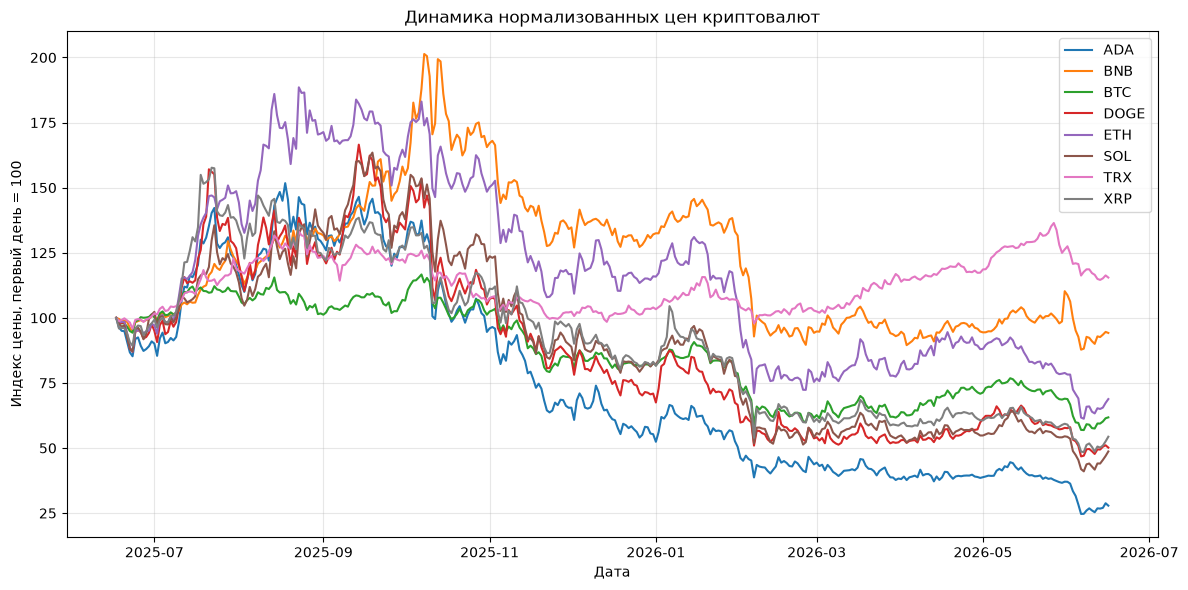

In [17]:
price_pivot = crypto_clean.pivot(
    index="date",
    columns="symbol",
    values="price"
)

normalized_prices = price_pivot / price_pivot.iloc[0] * 100

plt.figure(figsize=(12, 6))

for symbol in normalized_prices.columns:
    plt.plot(normalized_prices.index, normalized_prices[symbol], label=symbol)

plt.title("Динамика нормализованных цен криптовалют")
plt.xlabel("Дата")
plt.ylabel("Индекс цены, первый день = 100")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Сравнение накопленной доходности

На следующем графике сравнивается итоговая доходность криптовалют за весь рассматриваемый период.

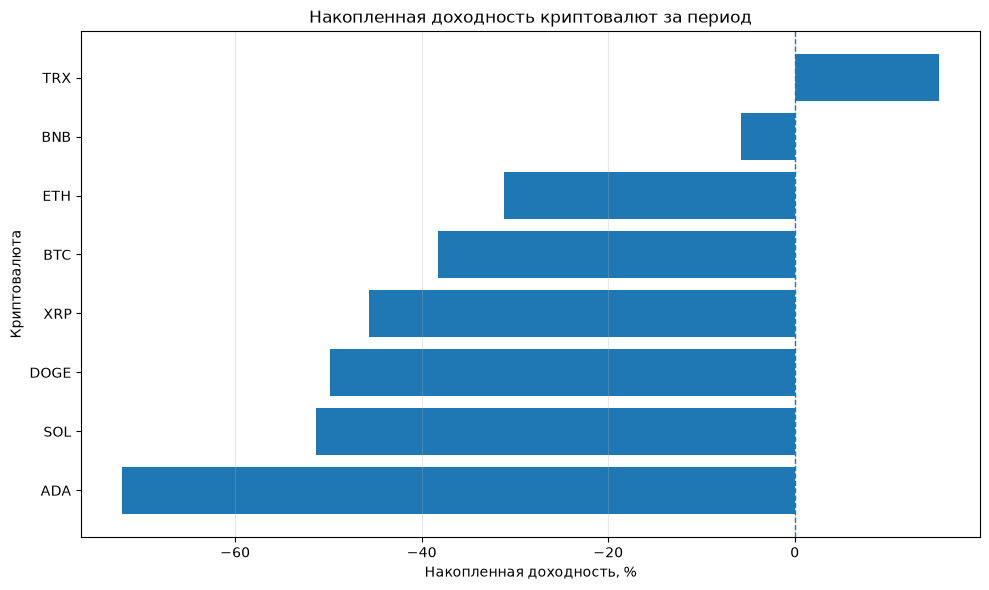

In [18]:
return_chart_data = summary.sort_values("cumulative_return", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    return_chart_data["symbol"],
    return_chart_data["cumulative_return"] * 100
)

plt.axvline(0, linestyle="--", linewidth=1)

plt.title("Накопленная доходность криптовалют за период")
plt.xlabel("Накопленная доходность, %")
plt.ylabel("Криптовалюта")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Сравнение волатильности

Волатильность показывает уровень риска актива.  
Чем выше значение, тем сильнее колебалась дневная доходность криптовалюты.

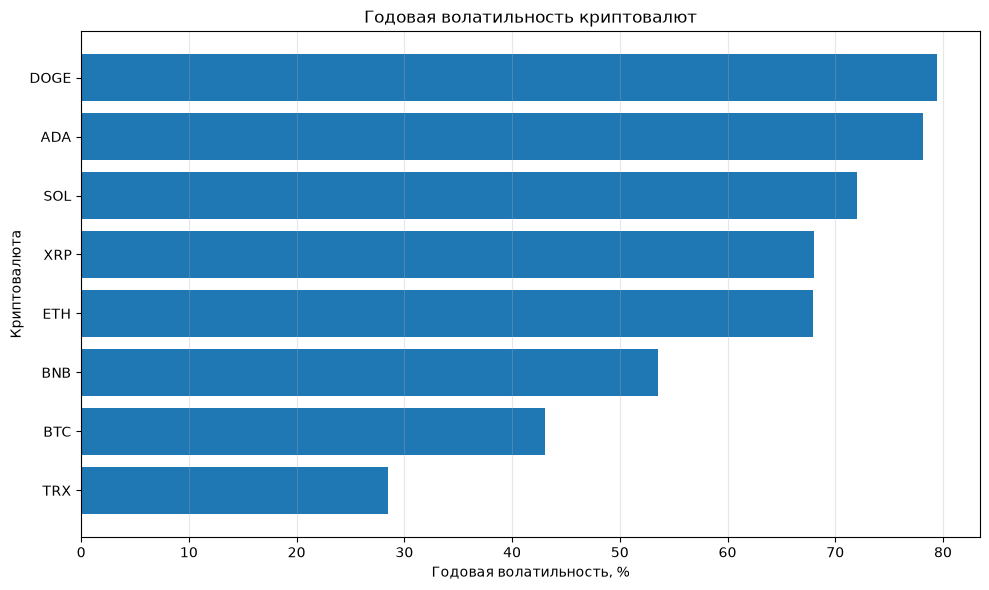

In [19]:
volatility_chart_data = summary.sort_values(
    "annualized_volatility",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    volatility_chart_data["symbol"],
    volatility_chart_data["annualized_volatility"] * 100
)

plt.title("Годовая волатильность криптовалют")
plt.xlabel("Годовая волатильность, %")
plt.ylabel("Криптовалюта")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Динамика 30-дневной волатильности

Для анализа изменения риска во времени используется 30-дневная скользящая волатильность.

Этот график показывает, в какие периоды рынок становился более нестабильным.

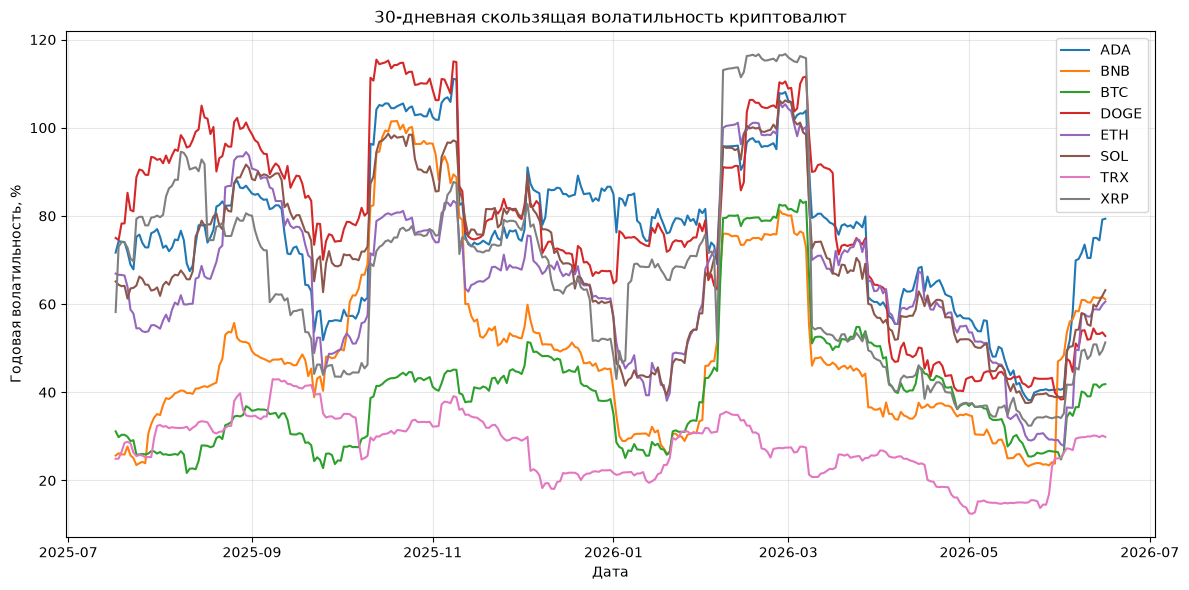

In [20]:
rolling_volatility_pivot = crypto_clean.pivot(
    index="date",
    columns="symbol",
    values="volatility_30d_pct"
)

plt.figure(figsize=(12, 6))

for symbol in rolling_volatility_pivot.columns:
    plt.plot(
        rolling_volatility_pivot.index,
        rolling_volatility_pivot[symbol],
        label=symbol
    )

plt.title("30-дневная скользящая волатильность криптовалют")
plt.xlabel("Дата")
plt.ylabel("Годовая волатильность, %")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Связь доходности и риска

Для сравнения криптовалют построим график риск-доходность.

По оси X расположена годовая волатильность, а по оси Y — накопленная доходность за период.

Такой график помогает понять, какие активы дали более высокую доходность при сопоставимом уровне риска.

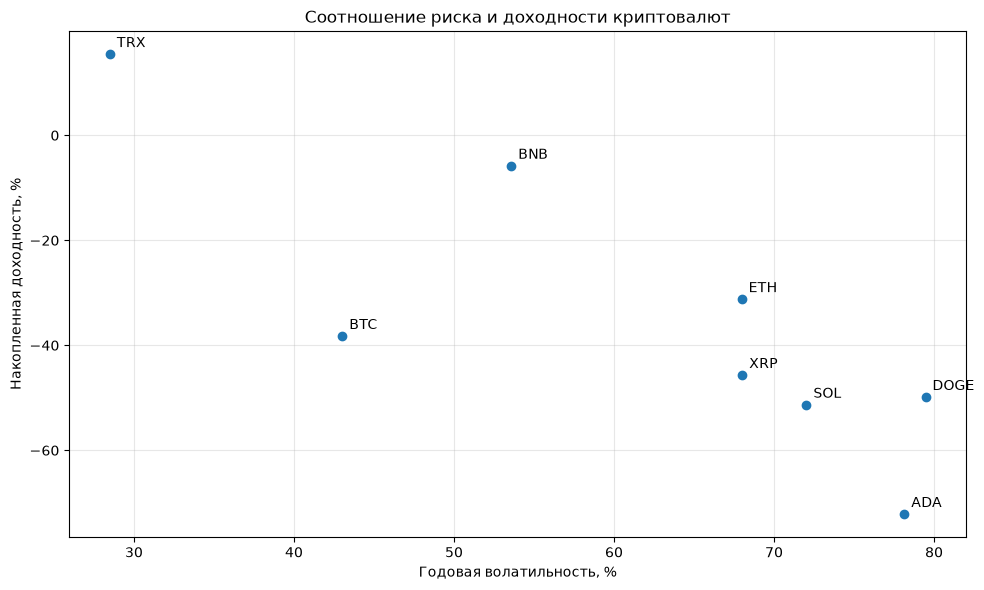

In [21]:
plt.figure(figsize=(10, 6))

x = summary["annualized_volatility"] * 100
y = summary["cumulative_return"] * 100

plt.scatter(x, y)

for _, row in summary.iterrows():
    plt.annotate(
        row["symbol"],
        (
            row["annualized_volatility"] * 100,
            row["cumulative_return"] * 100
        ),
        textcoords="offset points",
        xytext=(5, 5)
    )

plt.title("Соотношение риска и доходности криптовалют")
plt.xlabel("Годовая волатильность, %")
plt.ylabel("Накопленная доходность, %")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Корреляционная матрица доходностей

Корреляция показывает, насколько похожа динамика дневной доходности разных криптовалют.

Значение корреляции близкое к 1 означает, что активы часто движутся в одном направлении.  
Значение около 0 означает слабую связь.

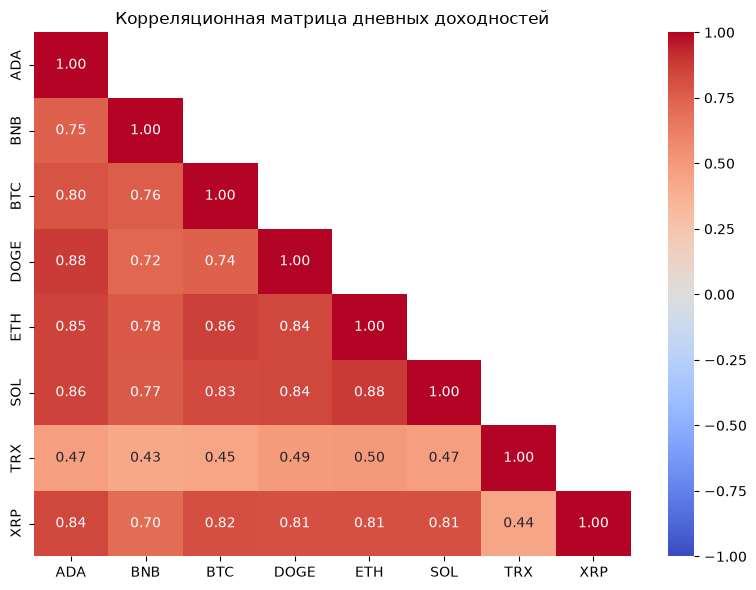

In [22]:
returns_pivot = crypto_clean.pivot(
    index="date",
    columns="symbol",
    values="daily_return"
)

correlation_matrix = returns_pivot.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)

plt.figure(figsize=(8, 6))

ax = sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set(xlabel=None, ylabel=None)

plt.title("Корреляционная матрица дневных доходностей")
plt.tight_layout()
plt.show()

## 14. Проверка исследовательских гипотез

**Гипотеза 1.** Bitcoin и Ethereum как крупнейшие криптовалюты имеют более низкую волатильность по сравнению с большинством альткоинов.

**Вывод:** гипотеза подтверждается частично. BTC действительно был менее волатильным, чем большинство альткоинов. ETH оказался более рискованным, чем BTC, BNB и TRX, поэтому для него гипотеза подтверждается не полностью.

**Гипотеза 2.** Криптовалюты с более высокой доходностью обычно связаны с более высоким уровнем риска.

**Вывод:** гипотеза не подтвердилась. Лучший результат показал TRX, хотя у него была самая низкая волатильность. При этом ADA и DOGE имели высокий риск, но отрицательную доходность.

**Гипотеза 3.** Доходности криптовалют положительно коррелируют между собой, так как рынок криптовалют часто движется под влиянием общих факторов.

**Вывод:** гипотеза подтвердилась. Все корреляции положительные. У большинства криптовалют связь сильная, часто выше 0.7. TRX выделяется: он тоже связан с рынком положительно, но слабее остальных.

**Гипотеза 4.** Мемкоин DOGE отличается более нестабильной динамикой по сравнению с крупными инфраструктурными криптовалютами.

**Вывод:** гипотеза подтвердилась. DOGE оказался самой волатильной криптовалютой в выборке. Это подтверждает, что мемкоины могут быть более нестабильными, чем крупные инфраструктурные проекты.


## 15. Итоговые выводы

За период с 17 июня 2025 по 16 июня 2026 года большинство криптовалют из выборки показали отрицательную доходность. Исключением стал TRX, который вырос на 15.48% и одновременно имел самую низкую годовую волатильность — 28.50%. Наиболее слабый результат показала ADA: её накопленная доходность составила -72.13%, а максимальная просадка достигла -83.73%.
Это говорит о том, что в рассматриваемый период рынок криптовалют в выборке в основном находился в фазе снижения. При этом активы демонстрировали высокую волатильность: у большинства криптовалют годовая волатильность превышала 50%, а у DOGE достигала 79.46%.
Корреляционный анализ показал, что доходности криптовалют в основном двигались в одном направлении. Это подтверждает гипотезу о наличии общерыночных факторов, влияющих на динамику разных криптоактивов.

TRX выделился на фоне остальных активов: он показал положительную доходность при минимальном уровне риска в выборке. Возможное объяснение этого результата может быть связано с практическим использованием сети TRON для переводов стейблкоинов, прежде всего USDT. Однако для подтверждения этой причины требуется отдельный анализ сетевой активности TRON и данных по обороту USDT